# Week 13: Tables, NumPy and Plotting — PHASE 3: Build a checkable report — Complete Worked Solutions

Reference for **all 12 exercises and the bridge**. Try the matching student exercise first, then compare your steps. Each solution contains its own inputs and runs without live prompts or external files. Exercises 1–8 are core; 9–12 remain optional practice.

**Prerequisites:** the matching week's examples and earlier weeks. Read the reasoning before running the code. `assert` checks a known result; a failed check stops with `AssertionError`, while silence means that particular check passed. Checks are evidence for the displayed cases, not a proof for every possible input.

Plot exercises save a PNG file in the current folder and display the figure. Every exercise code cell is self-contained; running all cells also works.

**Türkçe:** Önce öğrenci defterinde deneyin. Sonra adımları ve ara değişkenleri karşılaştırın. `assert` verilen örneklerde sonucu kontrol eder; çizim alıştırmaları PNG dosyasını geçerli klasöre kaydeder.


## Reading the worked solutions

Each section gives the problem, a plan, Python code, and an expected result or checks.
Try your own answer first. After comparing, close this notebook and solve a changed example.

An `assert condition` line checks that a result matches an expectation. If the condition is false,
Python raises `AssertionError`; it means that check failed. For decimal calculations, a check such
as `abs(actual - expected) < 0.001` allows a small rounding difference.

Some examples run several small test cases. A pair `(input_value, expected_result)` keeps an input
beside its expected answer. In `for value, expected in cases`, Python takes the two parts of each
pair and gives them those names. Follow the calculation inside the loop for one case at a time.

**Türkçe:** `assert`, beklenen sonuç ile gerçek sonucu karşılaştırır. Test başarısızsa önce girdiyi
ve ara değerleri incele. Birden fazla örnek varsa önce yalnızca bir örneğin adımlarını takip et.

File examples create sample files in the current runtime folder. Use a separate runtime for your
own practice so the worked answers do not supply hidden variables to it.

[Week 13 lesson](../notebooks/Week_13.ipynb) · [All solutions](README.md) · [Course guide](../STUDY_GUIDE.md)


## Exercise 1: Column Means with Loops (Easy)

The temperature table below has 12 rows (every 5 minutes) and 3 columns (sensors A, B, C). Using **plain Python loops only**, compute the mean of each column and print it with two decimals.

### Reasoning and plan

A column has no list of its own. For each column index, visit every row and add that row's value at the index. Divide by the number of rows at the end. This is the Part 1 pattern.

**Türkçe:** Sütun için ayrı liste yoktur. Her satırdan aynı indisteki değeri toplayıp satır sayısına böleriz.


In [1]:
# ✏️ [EX1] — worked solution
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]
names = ["A", "B", "C"]
means = []
for col in range(3):
    total = 0.0
    for row in temps:
        total += row[col]
    means.append(total / len(temps))
    print(f"Sensor {names[col]}: mean = {means[col]:.2f} C")
assert abs(means[0] - 23.792) < 0.01
assert abs(means[1] - 22.7) < 0.01
assert len(means) == 3
# Edge case: a one-row table returns that row as the means
one = [[5.0, 6.0, 7.0]]
assert [sum(r[c] for r in one) / len(one) for c in range(3)] == [5.0, 6.0, 7.0]


Sensor A: mean = 23.79 C
Sensor B: mean = 22.70 C
Sensor C: mean = 23.95 C


### Expected result

```text
Sensor A: mean = 23.79 C
Sensor B: mean = 22.70 C
Sensor C: mean = 23.95 C
```

The assertions also check the cases named in the code.


## Exercise 2: Column Means with NumPy (Easy)

Repeat Exercise 1 with NumPy. Convert `temps` to an array, print its shape, and print the per-sensor means with two decimals using one call with `axis=0`.

### Reasoning and plan

The array knows its shape, so `axis=0` collapses the 12 rows into one value per column. The loop of Exercise 1 becomes one line. Printing with two decimals keeps the report readable.

**Türkçe:** `axis=0` satırları toplar ve her sütun için tek değer bırakır. Döngü tek satıra iner.


In [2]:
# ✏️ [EX2] — worked solution
import numpy as np
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]
a = np.array(temps)
print("Shape:", a.shape)
means = a.mean(axis=0)
for name, m in zip(["A", "B", "C"], means):
    print(f"Sensor {name}: mean = {m:.2f} C")
assert a.shape == (12, 3)
assert means.shape == (3,)
assert abs(means[0] - 23.792) < 0.01
# Edge case: axis=1 gives one value per row instead
assert a.mean(axis=1).shape == (12,)


Shape: (12, 3)
Sensor A: mean = 23.79 C
Sensor B: mean = 22.70 C
Sensor C: mean = 23.95 C


### Expected result

```text
Shape: (12, 3)
Sensor A: mean = 23.79 C
Sensor B: mean = 22.70 C
Sensor C: mean = 23.95 C
```

The assertions also check the cases named in the code.


## Exercise 3: Beam Deflection mm to m (Easy)

A beam was loaded in steps and its deflection measured in millimetres. Convert the whole deflection column to **metres** with one array multiplication. Print a table of load (N) and deflection (m) with four decimals, then the maximum deflection in metres.

### Reasoning and plan

One multiplication converts every element; no loop is needed. Keep the original millimetre list so the raw measurement is not lost. The maximum is a property of the converted column.

**Türkçe:** Bir çarpma tüm sütunu dönüştürür. Ham mm değerlerini silmeyin; maksimum dönüştürülmüş sütundan okunur.


In [3]:
# ✏️ [EX3] — worked solution
import numpy as np
load_n = [0, 100, 200, 300, 400, 500]
deflection_mm = [0.00, 0.42, 0.85, 1.27, 1.70, 2.12]
deflection_m = np.array(deflection_mm) * 0.001
print(f"{'Load (N)':>8} {'Deflection (m)':>15}")
for load, d in zip(load_n, deflection_m):
    print(f"{load:>8} {d:>15.4f}")
print(f"Maximum deflection: {deflection_m.max():.4f} m")
assert abs(deflection_m[-1] - 0.00212) < 1e-9
assert deflection_m.shape == (6,)
# Edge case: zero load gives zero deflection in both units
assert deflection_m[0] == 0.0


Load (N)  Deflection (m)
       0          0.0000
     100          0.0004
     200          0.0008
     300          0.0013
     400          0.0017
     500          0.0021
Maximum deflection: 0.0021 m


### Expected result

```text
Load (N)  Deflection (m)
       0          0.0000
     100          0.0004
     200          0.0008
     300          0.0013
     400          0.0017
     500          0.0021
Maximum deflection: 0.0021 m
```

The assertions also check the cases named in the code.


## Exercise 4: Count Readings Above a Threshold (Medium)

Using the temperature table, count how many readings are above **24.0 °C**: in the whole table, and per sensor. Then print the values above the threshold for sensor A.

### Reasoning and plan

A comparison on the array gives a mask of the same shape. Summing the mask counts `True` values; summing along `axis=0` counts per column. Indexing a column with its own mask keeps only the readings that passed the test.

**Türkçe:** Karşılaştırma aynı şekilde bir maske verir. Maskeyi toplamak `True` sayısını verir; `axis=0` sütun başına sayar.


In [4]:
# ✏️ [EX4] — worked solution
import numpy as np
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]
threshold = 24.0
a = np.array(temps)
mask = a > threshold
print(f"Readings above {threshold} C: {mask.sum()} of {a.size}")
print("Per sensor:", mask.sum(axis=0))
sensor_a = a[:, 0]
print("Sensor A values above threshold:", " ".join(f"{v:.1f}" for v in sensor_a[mask[:, 0]]))
assert mask.sum() == 12
assert list(mask.sum(axis=0)) == [6, 0, 6]
# Edge case: a threshold above every reading gives zero
assert (a > 100.0).sum() == 0


Readings above 24.0 C: 12 of 36
Per sensor: [6 0 6]
Sensor A values above threshold: 24.1 24.5 24.7 24.9 25.0 25.2


### Expected result

```text
Readings above 24.0 C: 12 of 36
Per sensor: [6 0 6]
Sensor A values above threshold: 24.1 24.5 24.7 24.9 25.0 25.2
```

The assertions also check the cases named in the code.


## Exercise 5: Time of Maximum Current (Medium)

A motor current was logged every 0.5 s. Find the maximum current, the **position** of that maximum and the **time** at which it happened. Also print the mean current *without* that sample.

### Reasoning and plan

The largest value alone does not locate the event. `argmax` returns its position, and the same position in the time array gives the moment. Excluding the peak with a mask shows how much one sample moves the mean.

**Türkçe:** `argmax` en büyük değerin konumunu verir; aynı konum zaman dizisinde anı gösterir.


In [5]:
# ✏️ [EX5] — worked solution
import numpy as np
time_s = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5,
          5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5]
current_a = [2.0, 2.1, 2.0, 2.2, 2.1, 2.0, 2.3, 2.1, 2.2, 2.0,
             2.1, 2.2, 2.0, 2.1, 6.5, 2.2, 2.1, 2.0, 2.2, 2.1]
t = np.array(time_s)
current = np.array(current_a)
pos = int(np.argmax(current))
print(f"Maximum current: {current.max():.2f} A")
print(f"Position: {pos}, time: {t[pos]:.1f} s")
print(f"Mean with peak:    {current.mean():.3f} A")
without = current[current < current.max()]
print(f"Mean without peak: {without.mean():.3f} A")
assert pos == 14 and t[pos] == 7.0
assert len(without) == len(current) - 1
# Edge case: a flat signal has its maximum at position 0
assert np.argmax(np.array([2.0, 2.0, 2.0])) == 0


Maximum current: 6.50 A
Position: 14, time: 7.0 s
Mean with peak:    2.325 A
Mean without peak: 2.105 A


### Expected result

```text
Maximum current: 6.50 A
Position: 14, time: 7.0 s
Mean with peak:    2.325 A
Mean without peak: 2.105 A
```

The assertions also check the cases named in the code.


## Exercise 6: Moving Average with a Loop (Medium)

Smooth the motor current with a **3-point moving average**: for every position `i`, average `current[i]`, `current[i+1]` and `current[i+2]`. Use a loop over the NumPy array and store the results in a list. Print how many averages you get, the largest one with its centre time, and all averages on one line with two decimals.

### Reasoning and plan

Each window is a slice of three neighbours, so the loop runs to `len - 2`. The spike is shared by three windows, so the smoothed peak is lower than 6.5 A. The centre time labels the window.

**Türkçe:** Her pencere üç komşunun dilimidir; döngü `len - 2` kez çalışır. Ani sıçrama üç pencereye yayılır.


In [6]:
# ✏️ [EX6] — worked solution
import numpy as np
time_s = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5,
          5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5]
current_a = [2.0, 2.1, 2.0, 2.2, 2.1, 2.0, 2.3, 2.1, 2.2, 2.0,
             2.1, 2.2, 2.0, 2.1, 6.5, 2.2, 2.1, 2.0, 2.2, 2.1]
t = np.array(time_s)
current = np.array(current_a)
averages = []
for i in range(len(current) - 2):
    window = current[i:i + 3]
    averages.append(window.mean())
averages = np.array(averages)
best = int(np.argmax(averages))
print(f"Number of averages: {len(averages)}")
print(f"Largest average: {averages[best]:.2f} A at centre time {t[best + 1]:.1f} s")
print("All:", " ".join(f"{v:.2f}" for v in averages))
assert len(averages) == len(current) - 2
assert abs(averages[13] - (2.1 + 6.5 + 2.2) / 3) < 1e-9
# Edge case: optional check with np.convolve gives the same numbers
assert np.allclose(averages, np.convolve(current, np.ones(3) / 3, mode="valid"))


Number of averages: 18
Largest average: 3.60 A at centre time 7.0 s
All: 2.03 2.10 2.10 2.10 2.13 2.13 2.20 2.10 2.10 2.10 2.10 2.10 3.53 3.60 3.60 2.10 2.10 2.10


### Expected result

```text
Number of averages: 18
Largest average: 3.60 A at centre time 7.0 s
All: 2.03 2.10 2.10 2.10 2.13 2.13 2.20 2.10 2.10 2.10 2.10 2.10 3.53 3.60 3.60 2.10 2.10 2.10
```

The assertions also check the cases named in the code.


## Exercise 7: Plot One Sensor (Medium)

Plot sensor A of the temperature table against time in minutes (0, 5, …, 55). Add axis labels with units, a title and a grid. Save the figure as `sensor_a.png` and print a confirmation that the file exists.

### Reasoning and plan

The x-axis is built with `np.arange` so it matches the 12 rows. Labels with units make the picture readable without the code. Saving is a file write, so the file's existence is the check that the write happened.

**Türkçe:** `np.arange` 12 satıra uyan bir zaman ekseni üretir. Kaydetme bir dosya yazmadır; dosyanın varlığı kontroldür.


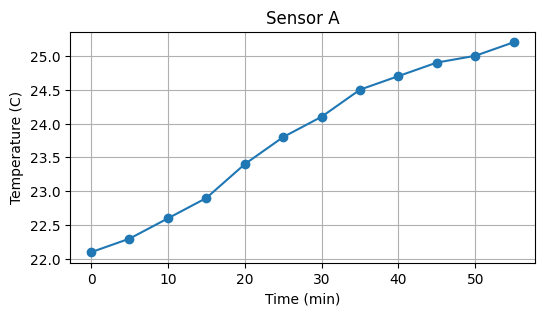

Saved sensor_a.png: True


In [7]:
# ✏️ [EX7] — worked solution
import numpy as np
import matplotlib.pyplot as plt
import os
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]
a = np.array(temps)
minutes = np.arange(0, 60, 5)
plt.figure(figsize=(6, 3))
plt.plot(minutes, a[:, 0], marker="o")
plt.xlabel("Time (min)")
plt.ylabel("Temperature (C)")
plt.title("Sensor A")
plt.grid(True)
plt.savefig("sensor_a.png")
plt.show()
print("Saved sensor_a.png:", os.path.exists("sensor_a.png"))
assert os.path.exists("sensor_a.png")
assert os.path.getsize("sensor_a.png") > 0
# Edge case: the time axis has one entry per table row
assert len(minutes) == a.shape[0]


### Expected result

```text
Saved sensor_a.png: True
```

The assertions also check the cases named in the code.


## Exercise 8: Plot Three Sensors with a Legend (Medium)

Plot all three sensors on one figure with a legend (`Sensor A`, `Sensor B`, `Sensor C`), labels with units, a title and a grid. Save it as `sensors.png`. Then print which sensor has the largest final reading.

### Reasoning and plan

One `plt.plot` per column adds a line; the legend uses each `label`. The last row is `a[-1, :]`, and `argmax` names the column with the largest value. The plot shows the trend; the printed line gives the checkable number.

**Türkçe:** Her sütun için bir `plt.plot` çizgi ekler. Son satır `a[-1, :]`, en büyük değerin sütunu `argmax` ile bulunur.


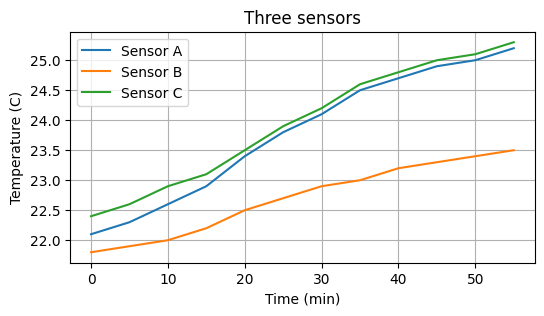

Saved sensors.png: True
Largest final reading: Sensor C at 25.3 C


In [8]:
# ✏️ [EX8] — worked solution
import numpy as np
import matplotlib.pyplot as plt
import os
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]
a = np.array(temps)
minutes = np.arange(0, 60, 5)
names = ["A", "B", "C"]
plt.figure(figsize=(6, 3))
for col in range(3):
    plt.plot(minutes, a[:, col], label=f"Sensor {names[col]}")
plt.xlabel("Time (min)")
plt.ylabel("Temperature (C)")
plt.title("Three sensors")
plt.grid(True)
plt.legend()
plt.savefig("sensors.png")
plt.show()
last = a[-1, :]
top = int(np.argmax(last))
print(f"Saved sensors.png: {os.path.exists('sensors.png')}")
print(f"Largest final reading: Sensor {names[top]} at {last[top]:.1f} C")
assert os.path.exists("sensors.png")
assert top == 2
# Edge case: every sensor ends warmer than it started
assert (a[-1, :] > a[0, :]).all()


### Expected result

```text
Saved sensors.png: True
Largest final reading: Sensor C at 25.3 C
```

The assertions also check the cases named in the code.


## Exercise 9: Normalise Each Column (z-score) (Medium)

Normalise the temperature table so that each **column** has mean 0 and standard deviation 1: `z = (a - mean) / std` with the mean and std computed per column (`axis=0`). Print the first two rows of `z` with two decimals and confirm the new column means are 0.

### Reasoning and plan

Subtracting a 3-value array from a 12×3 array applies it to every row: this is broadcasting. After the operation each column is centred on 0 and scaled by its own spread. The check is that the new means are 0 within rounding.

**Türkçe:** Üç değerli dizi her satıra uygulanır (broadcasting). Yeni sütun ortalamaları sıfıra yakın olmalıdır.


In [9]:
# ✏️ [EX9] — worked solution
import numpy as np
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]
a = np.array(temps)
mean = a.mean(axis=0)
std = a.std(axis=0)
z = (a - mean) / std
print("Row 0:", " ".join(f"{v:6.2f}" for v in z[0]))
print("Row 1:", " ".join(f"{v:6.2f}" for v in z[1]))
print("Column means are 0:", bool(np.abs(z.mean(axis=0)).max() < 1e-9))
print("Column stds are 1: ", bool(np.abs(z.std(axis=0) - 1).max() < 1e-9))
assert z.shape == a.shape
assert np.allclose(z.mean(axis=0), 0.0)
assert np.allclose(z.std(axis=0), 1.0)
# Edge case: the first row is below the mean in every column
assert (z[0] < 0).all()


Row 0:  -1.59  -1.54  -1.57
Row 1:  -1.40  -1.37  -1.37
Column means are 0: True
Column stds are 1:  True


### Expected result

```text
Row 0:  -1.59  -1.54  -1.57
Row 1:  -1.40  -1.37  -1.37
Column means are 0: True
Column stds are 1:  True
```

The assertions also check the cases named in the code.


## Exercise 10: Detect Spikes with |diff| > k·std (Medium)

Detect spikes in the motor current: compute the differences between neighbours with `np.diff(current)`, then flag every step where `abs(diff) > k * std(diff)` with `k = 2.0`. Print the flagged positions and their times, and the number of flags.

### Reasoning and plan

A spike produces one large positive step and one large negative step, so two differences are flagged. The threshold is relative to the signal's own spread, not a fixed ampere value. `np.where` turns the mask into positions.

**Türkçe:** Ani sıçrama bir büyük artı, bir büyük eksi fark üretir; iki adım işaretlenir. Eşik sinyalin kendi yayılımına göredir.


In [10]:
# ✏️ [EX10] — worked solution
import numpy as np
time_s = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5,
          5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5]
current_a = [2.0, 2.1, 2.0, 2.2, 2.1, 2.0, 2.3, 2.1, 2.2, 2.0,
             2.1, 2.2, 2.0, 2.1, 6.5, 2.2, 2.1, 2.0, 2.2, 2.1]
k = 2.0
t = np.array(time_s)
current = np.array(current_a)
diff = np.diff(current)
limit = k * diff.std()
flags = np.abs(diff) > limit
positions = np.where(flags)[0]
print(f"Threshold: {limit:.3f} A")
print("Flagged steps:", positions.tolist())
for p in positions:
    print(f"  step {p}: {t[p]:.1f} s -> {t[p + 1]:.1f} s, change {diff[p]:+.2f} A")
print("Number of flags:", flags.sum())
assert len(diff) == len(current) - 1
assert list(positions) == [13, 14]
# Edge case: a constant signal has std 0 and no flags
flat = np.diff(np.array([2.0, 2.0, 2.0]))
assert (np.abs(flat) > k * flat.std()).sum() == 0


Threshold: 2.838 A


Flagged steps: [13, 14]
  step 13: 6.5 s -> 7.0 s, change +4.40 A
  step 14: 7.0 s -> 7.5 s, change -4.30 A
Number of flags: 2


### Expected result

```text
Threshold: 2.838 A
Flagged steps: [13, 14]
  step 13: 6.5 s -> 7.0 s, change +4.40 A
  step 14: 7.0 s -> 7.5 s, change -4.30 A
Number of flags: 2
```

The assertions also check the cases named in the code.


## Exercise 11: Trapezoid Integration of a Velocity Log (Medium)

A vehicle's speed was logged every 0.5 s. Estimate the distance travelled with the **trapezoid rule** in a loop: each step adds `(v[i] + v[i+1]) / 2 * (t[i+1] - t[i])`. Print the distance with three decimals, then compare with NumPy's `np.trapezoid` (older versions call it `np.trapz`).

### Reasoning and plan

Each pair of samples forms a trapezoid whose area is the average height times the width. Summing them approximates the integral of speed, which is distance. NumPy's function does the same sum, so the two results should agree to rounding.

**Türkçe:** Her örnek çifti bir yamuktur; alan ortalama yükseklik çarpı genişliktir. Toplam, hızın integrali yani yoldur.


In [11]:
# ✏️ [EX11] — worked solution
import numpy as np
t_s = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
v_ms = [0.0, 0.5, 1.1, 1.8, 2.4, 3.0, 3.4, 3.7, 3.9, 4.0, 4.0]
t = np.array(t_s)
v = np.array(v_ms)
distance = 0.0
for i in range(len(t) - 1):
    distance += (v[i] + v[i + 1]) / 2 * (t[i + 1] - t[i])
trap = getattr(np, "trapezoid", None) or np.trapz
numpy_distance = trap(v, t)
print(f"Loop distance:  {distance:.3f} m")
print(f"NumPy distance: {numpy_distance:.3f} m")
print(f"Agree: {abs(distance - numpy_distance) < 1e-9}")
assert abs(distance - numpy_distance) < 1e-9
assert abs(distance - 12.9) < 1e-9
# Edge case: constant speed gives speed * time exactly
assert abs(trap(np.array([2.0, 2.0, 2.0]), np.array([0.0, 1.0, 2.0])) - 4.0) < 1e-12


Loop distance:  12.900 m
NumPy distance: 12.900 m
Agree: True


### Expected result

```text
Loop distance:  12.900 m
NumPy distance: 12.900 m
Agree: True
```

The assertions also check the cases named in the code.


## Exercise 12: Calibration Line Fit (Challenge)

A pressure sensor gives a voltage for known pressures. Fit a straight line `voltage = slope * pressure + intercept` with `np.polyfit(x, y, 1)`. Print the slope (V/kPa, five decimals) and intercept (V, three decimals), the residual for each point (three decimals) and the largest absolute residual. Plot the points and the fitted line, and save `calibration.png`. Then use the fit to convert a reading of 1.75 V back to pressure.

### Reasoning and plan

`polyfit` finds the slope and intercept that minimise the squared residuals. The residuals show how far each point is from the line; their maximum is a simple quality number for the report. The inverse formula turns the calibration into a measurement tool.

**Türkçe:** `polyfit` kareler toplamını en küçük yapan doğruyu bulur. Artıklar her noktanın doğruya uzaklığıdır; ters formül voltajı basınca çevirir.


Slope: 0.00493 V/kPa
Intercept: 0.525 V
      0 kPa residual -0.005 V
    100 kPa residual +0.012 V
    200 kPa residual -0.022 V
    300 kPa residual +0.015 V
    400 kPa residual +0.012 V
    500 kPa residual -0.012 V
Largest |residual|: 0.022 V
1.75 V -> 248.3 kPa


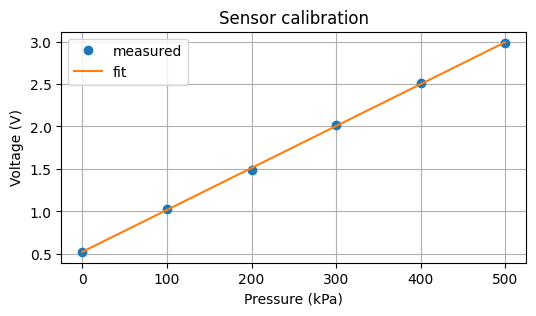

Saved calibration.png: True


In [12]:
# ✏️ [EX12] — worked solution
import numpy as np
import matplotlib.pyplot as plt
import os
pressure_kpa = [0, 100, 200, 300, 400, 500]
voltage_v = [0.52, 1.03, 1.49, 2.02, 2.51, 2.98]
reading_v = 1.75
x = np.array(pressure_kpa, dtype=float)
y = np.array(voltage_v)
slope, intercept = np.polyfit(x, y, 1)
fitted = slope * x + intercept
residuals = y - fitted
print(f"Slope: {slope:.5f} V/kPa")
print(f"Intercept: {intercept:.3f} V")
for p, r in zip(x, residuals):
    print(f"  {p:5.0f} kPa residual {r:+.3f} V")
print(f"Largest |residual|: {np.abs(residuals).max():.3f} V")
pressure = (reading_v - intercept) / slope
print(f"{reading_v} V -> {pressure:.1f} kPa")

plt.figure(figsize=(6, 3))
plt.plot(x, y, "o", label="measured")
plt.plot(x, fitted, label="fit")
plt.xlabel("Pressure (kPa)")
plt.ylabel("Voltage (V)")
plt.title("Sensor calibration")
plt.grid(True)
plt.legend()
plt.savefig("calibration.png")
plt.show()
print("Saved calibration.png:", os.path.exists("calibration.png"))
assert abs(slope - 0.00493) < 0.0001
assert abs(intercept - 0.526) < 0.01
assert np.abs(residuals).max() < 0.03
# Edge case: the inverse of the fit recovers the fitted x exactly
assert np.allclose((fitted - intercept) / slope, x)


### Expected result

```text
Slope: 0.00493 V/kPa
Intercept: 0.525 V
      0 kPa residual -0.005 V
    100 kPa residual +0.012 V
    200 kPa residual -0.022 V
    300 kPa residual +0.015 V
    400 kPa residual +0.012 V
    500 kPa residual -0.012 V
Largest |residual|: 0.022 V
1.75 V -> 248.3 kPa
Saved calibration.png: True
```

The assertions also check the cases named in the code.


## Bridge Exercise: Preview of the capstone

Next week you will build the **capstone sensor report**: read a log, compute per-sensor statistics, check limits and save a report.

As a preview, write a CSV file called `data.csv` from the string below, read it back into a NumPy array, compute the mean of each sensor and print a **one-line report**.

```python
csv_text = """minute,sensor_a,sensor_b,sensor_c
0,22.1,21.8,22.4
5,22.3,21.9,22.6
10,22.6,22.0,22.9
15,22.9,22.2,23.1
20,23.4,22.5,23.5
"""
```

### Reasoning and plan

Writing the string to a file makes the example self-contained. `np.loadtxt` skips the header and returns a 5×4 array; column 0 is the minute, so the sensors are `data[:, 1:]`. One `mean(axis=0)` gives the three numbers for the report.

**Türkçe:** Metni dosyaya yazıp `np.loadtxt` ile okuruz. Sütun 0 zaman olduğundan sensörler `data[:, 1:]` dilimindedir.


In [13]:
# ✏️ [EXBridge] — worked solution
import numpy as np

csv_text = """minute,sensor_a,sensor_b,sensor_c
0,22.1,21.8,22.4
5,22.3,21.9,22.6
10,22.6,22.0,22.9
15,22.9,22.2,23.1
20,23.4,22.5,23.5
"""

with open("data.csv", "w") as file:
    file.write(csv_text)

data = np.loadtxt("data.csv", delimiter=",", skiprows=1)
sensors = data[:, 1:]
means = sensors.mean(axis=0)
print(f"Report: {data.shape[0]} rows, sensor means A={means[0]:.2f} B={means[1]:.2f} C={means[2]:.2f} C")
assert data.shape == (5, 4)
assert abs(means[0] - 22.66) < 0.01
# Edge case: the minute column is not part of the sensor means
assert sensors.shape[1] == 3


Report: 5 rows, sensor means A=22.66 B=22.08 C=22.90 C


### Expected result

```text
Report: 5 rows, sensor means A=22.66 B=22.08 C=22.90 C
```

The assertions also check the cases named in the code.
